In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [14]:
try:

 # Analisar sequestro
 # 1. Comportamento temporal (ano)
 # 2. Qual região teve mais SEQUESTRO
 # Analisar roubo_celular
 # 1. Qual epoca do ano é mais propenso?
 # 2. Existem DPs que registram muito mais ocorrencias?
    dados = pd.read_csv('03.BaseDPEvolucaoMensalCisp.csv', sep=';', encoding='iso-8859-1')
    dp = pd.read_csv('08.DP.csv', sep=',', encoding='utf-8')
    print(dp)
    print(dados.columns)
 # juntar dados 
    df_comDP = dados.merge(dp, left_on='cisp', right_on='codDP', how='left')
    df_sequestro =df_comDP[['cisp', 'sequestro', 'ano', 'codDP', 'regiao',]]
    df_sequestro_ano = df_sequestro.groupby('ano').sum().reset_index()
    #print(df_sequestro_ano)
    df_sequestro_região = df_sequestro.groupby('regiao')['sequestro'].sum().reset_index().sort_values('sequestro', ascending=False)
    

except Exception as e:
    print(f'Erro ao processar dados: {e}')

     codDP                           nome  \
0        1   001ª DP - Praça da República   
1        4   004ª DP - Praça da República   
2        5            005ª DP - Mem de Sá   
3        6          006ª DP - Cidade Nova   
4        7         007ª DP - Santa Teresa   
..     ...                            ...   
132    159  159ª DP - Cachoeira de Macacu   
133    165          165ª DP - Mangaratiba   
134    166       166ª DP - Angra dos Reis   
135    167               167ª DP - Paraty   
136    168            168ª DP - Rio Claro   

                                              endereco  
0    Av. Presidente Vargas, 1100 - Centro, Rio de J...  
1    Av. Presidente Vargas, 1100 - Centro, Rio de J...  
2    Avenida Gomes Freire, 320 - Centro, Rio de Jan...  
3    Rua Professor Clementino Fraga, 77 - Centro, R...  
4    Rua Francisco de Castro, 5 - Santa Teresa, Rio...  
..                                                 ...  
132  Avenida Lord Baden Powel, 93 - Centro, Cachoei...  
133

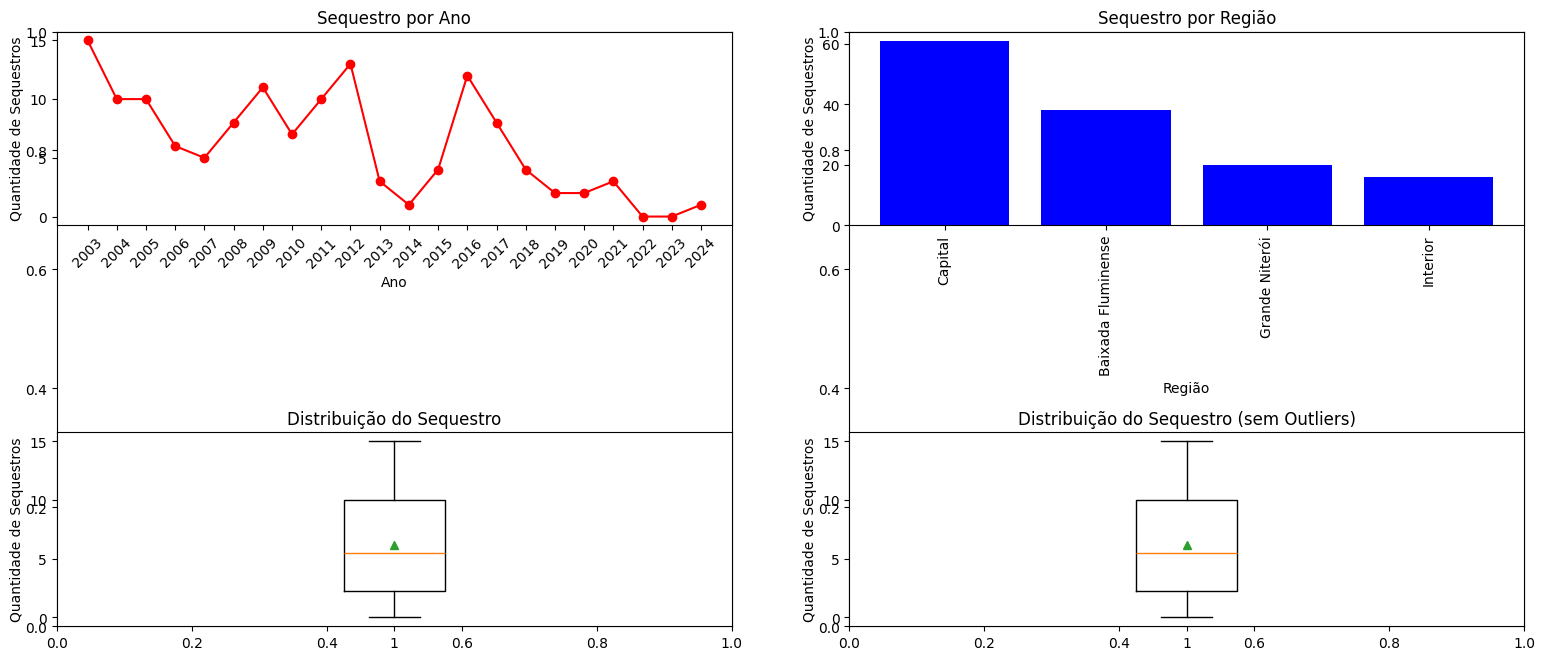

In [24]:
# VIZUALIZAÇÃO
try:
 
    # CRIAÇÃO DE UMA AREA DE GRAFICOS (2,2)-> 4 ESPAÇOS 
 plt.subplots(1,2, figsize=(16,7))

 # primeiro grafico => por ano(linha)
 # dubplot -> (x,y,z) -> x,y,z repetem valor do subplots z é a pozição que o grafico vai ficar no subplot

 plt.subplot(2,2,1)
 plt.plot(df_sequestro_ano['ano'].astype(str), df_sequestro_ano['sequestro'], marker='o', color='red')
 plt.title('Sequestro por Ano')
 plt.xlabel('Ano')
 plt.ylabel('Quantidade de Sequestros')
 plt.xticks(rotation=45)
 # segundo grafico 
 plt.subplot(2,2,2)
 plt.bar(df_sequestro_região['regiao'], df_sequestro_região['sequestro'], color='blue')
 plt.title('Sequestro por Região')
 plt.xlabel('Região')
 plt.ylabel('Quantidade de Sequestros')
 plt.xticks(rotation=90)
 
 # terceiro grafico -> boxplot
 plt.subplot(2,2,3)
 plt.boxplot(df_sequestro_ano['sequestro'], showmeans=True, showfliers=True)
 plt.title('Distribuição do Sequestro')
 plt.ylabel('Quantidade de Sequestros')
 

 # Quarto grafico -> boxplot sem outliers
 plt.subplot(2,2,4)
 plt.boxplot(df_sequestro_ano['sequestro'], showmeans=True, showfliers=False)
 plt.title('Distribuição do Sequestro (sem Outliers)')
 plt.ylabel('Quantidade de Sequestros')
 

 
 plt.tight_layout()

except Exception as e:
    print(f"Ocorreu um erro: {e}")